# Mapas do Brasil - Vacinação contra sarampo (jan/2025 a jun/2026)

Visualizações geográficas das doses de vacina com componente de sarampo, por UF e por município de residência do paciente.

**Fontes**
- Doses: tabelas gold e silver em `data/vacinacao/processed/` (ver [05](05-silver-qualidade-vacinacao.ipynb) a [08](08-eda-completa-vacinacao-sarampo.ipynb)).
- Malhas de UF e município e população estimada por município (IBGE, 2026): baixadas por `data/geo/baixar_malhas.py`.

**Método:** os mapas são desenhados com `matplotlib` a partir do GeoJSON do IBGE (qualidade mínima, suficiente para escala nacional), sem depender de geopandas. Taxas usam a **população estimada de 2026 como denominador aproximado** para todo o período de 18 meses. Isso serve para comparar territórios entre si, mas não é cobertura vacinal (não há denominador por idade).

Índice: 1. Doses por 1.000 habitantes (UF) · 2. Mesma taxa por município · 3. Onde as doses se concentram (bolhas) · 4. Evolução por trimestre · 5. 2026 x 2025 · 6. Crianças com 2+ doses · 7. Adultos · 8. Atraso de registro · 9. Fluxos interestaduais · 10. Síntese

## 1. Setup e dados

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
from matplotlib.collections import PolyCollection
from matplotlib.patches import FancyArrowPatch
import numpy as np
import pandas as pd

BLUE = "#2a78d6"
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TEXT_PRIMARY, TEXT_SECONDARY, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
SEM_DADO = "#d9d8d0"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "text.color": TEXT_PRIMARY, "font.size": 10,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT_SECONDARY, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
})

RAIZ = Path("..") / "data"
GOLD = RAIZ / "vacinacao" / "processed" / "gold"
SILVER = RAIZ / "vacinacao" / "processed" / "silver" / "vacinacao_sarampo_sipni.parquet"
GEO = RAIZ / "geo"

# ---------------------------------------------------------------- geometrias (GeoJSON do IBGE, sem geopandas)
def ler_geojson(caminho, chave_len):
    """Retorna (codigos, poligonos, dono): um anel externo por polígono, e `dono` liga cada
    polígono ao índice da feição (MultiPolygon gera vários polígonos por município/UF)."""
    features = json.loads(Path(caminho).read_text(encoding="utf-8"))["features"]
    codigos, verts, dono = [], [], []
    for i, f in enumerate(features):
        codigos.append(f["properties"]["codarea"][:chave_len])
        g = f["geometry"]
        aneis = [g["coordinates"][0]] if g["type"] == "Polygon" else [p[0] for p in g["coordinates"]]
        for anel in aneis:
            verts.append(np.asarray(anel)); dono.append(i)
    return codigos, verts, np.array(dono)


def centroide(anel):
    x, y = anel[:, 0], anel[:, 1]
    a = x[:-1] * y[1:] - x[1:] * y[:-1]
    area = a.sum() / 2
    if abs(area) < 1e-12:
        return anel.mean(axis=0)
    return np.array([((x[:-1] + x[1:]) * a).sum(), ((y[:-1] + y[1:]) * a).sum()]) / (6 * area)


def centroides(codigos, verts, dono):
    """Centroide do maior polígono de cada feição."""
    out = {}
    for i, cod in enumerate(codigos):
        cand = [v for v, d in zip(verts, dono) if d == i]
        out[cod] = centroide(max(cand, key=len))
    return out


uf_meta = pd.DataFrame(json.loads((GEO / "uf_meta.json").read_text(encoding="utf-8")))
ID_PARA_SIGLA = dict(zip(uf_meta["id"].astype(str), uf_meta["sigla"]))
SIGLA_PARA_ID = {v: k for k, v in ID_PARA_SIGLA.items()}
REGIAO = dict(zip(uf_meta["sigla"], uf_meta["regiao"].map(lambda r: r["nome"])))

cod_uf, verts_uf, dono_uf = ler_geojson(GEO / "uf.json", 2)
sigla_uf = [ID_PARA_SIGLA[c] for c in cod_uf]
cod_mun, verts_mun, dono_mun = ler_geojson(GEO / "municipios.json", 6)
cent_uf = {s: centroide(max([v for v, d in zip(verts_uf, dono_uf) if d == i], key=len))
           for i, s in enumerate(sigla_uf)}

LIM_X, LIM_Y = (-74.2, -33.5), (-34.2, 5.6)
ASPECTO = 1 / np.cos(np.radians(-15))


def base_mapa(ax, contorno_uf=True, cor_uf="white", lw=0.6):
    ax.set_xlim(*LIM_X); ax.set_ylim(*LIM_Y); ax.set_aspect(ASPECTO); ax.axis("off")
    if contorno_uf:
        ax.add_collection(PolyCollection(verts_uf, facecolors="none", edgecolors=cor_uf, linewidths=lw, zorder=3))


def coropletico(ax, valores, nivel="uf", bins=None, cmap="Blues", extremos="neither", titulo=None,
                rotulo=None, colorbar=True, contorno_uf=True, fmt="{:,.0f}", cbar_kw=None):
    """Mapa coroplético. `valores`: dict sigla->valor (nivel='uf') ou codigo6->valor ('mun').
    `bins`: limites das classes (BoundaryNorm) para dar cor discreta e legível."""
    if nivel == "uf":
        verts, dono, chaves = verts_uf, dono_uf, sigla_uf
    else:
        verts, dono, chaves = verts_mun, dono_mun, cod_mun
    v = np.array([valores.get(c, np.nan) for c in chaves], dtype=float)[dono]
    cm = plt.get_cmap(cmap).copy(); cm.set_bad(SEM_DADO)
    norm = mcolors.BoundaryNorm(bins, cm.N, extend=extremos) if bins is not None else None
    pc = PolyCollection(verts, array=np.ma.masked_invalid(v), cmap=cm, norm=norm,
                        edgecolors="white" if nivel == "uf" else "none", linewidths=0.5 if nivel == "uf" else 0, zorder=1)
    ax.add_collection(pc)
    base_mapa(ax, contorno_uf=contorno_uf and nivel != "uf")
    if titulo:
        ax.set_title(titulo, loc="left", fontweight="bold")
    if colorbar:
        kw = dict(shrink=0.55, pad=0.01, aspect=22); kw.update(cbar_kw or {})
        cb = plt.colorbar(pc, ax=ax, **kw)
        cb.ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: fmt.format(x).replace(",", ".")))
        if rotulo:
            cb.set_label(rotulo)
    return pc


def rotular_uf(ax, valores=None, fmt="{:.0f}", tamanho=7.5, so_sigla=False, limiar=None, escuro=None):
    """Rótulo de sigla (e valor) no centroide de cada UF; texto branco onde o fundo é escuro
    (valor acima de `limiar` ou sigla em `escuro`)."""
    for s, (x, y) in cent_uf.items():
        txt = s if so_sigla or valores is None else f"{s}\n" + fmt.format(valores.get(s, np.nan))
        cor = TEXT_PRIMARY
        if escuro is not None:
            cor = "white" if s in escuro else TEXT_PRIMARY
        elif valores is not None and limiar is not None and valores.get(s, 0) > limiar:
            cor = "white"
        ax.text(x, y, txt, ha="center", va="center", fontsize=tamanho, color=cor, zorder=6, linespacing=0.95)


def quantis(valores, n=7):
    v = pd.Series(list(valores.values() if isinstance(valores, dict) else valores)).dropna()
    b = np.unique(np.round(v.quantile(np.linspace(0, 1, n + 1)).values, 3))
    b[0], b[-1] = b[0] - 1e-9, b[-1] + 1e-9
    return b

dim = pd.read_csv(GOLD / "dim_municipios.csv", dtype={"codigo_municipio": str})
pop = pd.read_csv(GEO / "populacao_municipios.csv", dtype={"codigo_municipio": str})
pop["uf"] = pop["codigo_municipio"].str[:2].map(ID_PARA_SIGLA)
pop_mun = pop.set_index("codigo_municipio")["populacao"]
pop_uf = pop.groupby("uf")["populacao"].sum()

uf_mes = pd.read_parquet(GOLD / "gold_doses_uf_mes.parquet")
mun_mes = pd.read_parquet(GOLD / "gold_municipio_mes.parquet")
perfil = pd.read_parquet(GOLD / "gold_perfil.parquet")
atraso = pd.read_parquet(GOLD / "gold_atraso_registro.parquet")
coorte = pd.read_parquet(GOLD / "gold_coorte_criancas_municipio.parquet")

print(f"{len(cod_mun)} municípios e {len(cod_uf)} UFs na malha | população total {pop['populacao'].sum():,} ({pop['ano'].iloc[0]})")
doses_uf = uf_mes.groupby("uf_paciente")["doses"].sum()
doses_mun = mun_mes.groupby("codigo_municipio_paciente")["doses"].sum()
print(f"Doses: {doses_uf.sum():,} | em UF sem malha (ex.: XX): {doses_uf[~doses_uf.index.isin(sigla_uf)].sum():,}")

5570 municípios e 27 UFs na malha | população total 214,211,951 (2026)
Doses: 11,558,568 | em UF sem malha (ex.: XX): 2


## 2. Doses por 1.000 habitantes, por UF
Volume absoluto acompanha o tamanho do estado (SP domina); a taxa por habitante mostra **onde se vacinou mais em relação ao tamanho da população**.

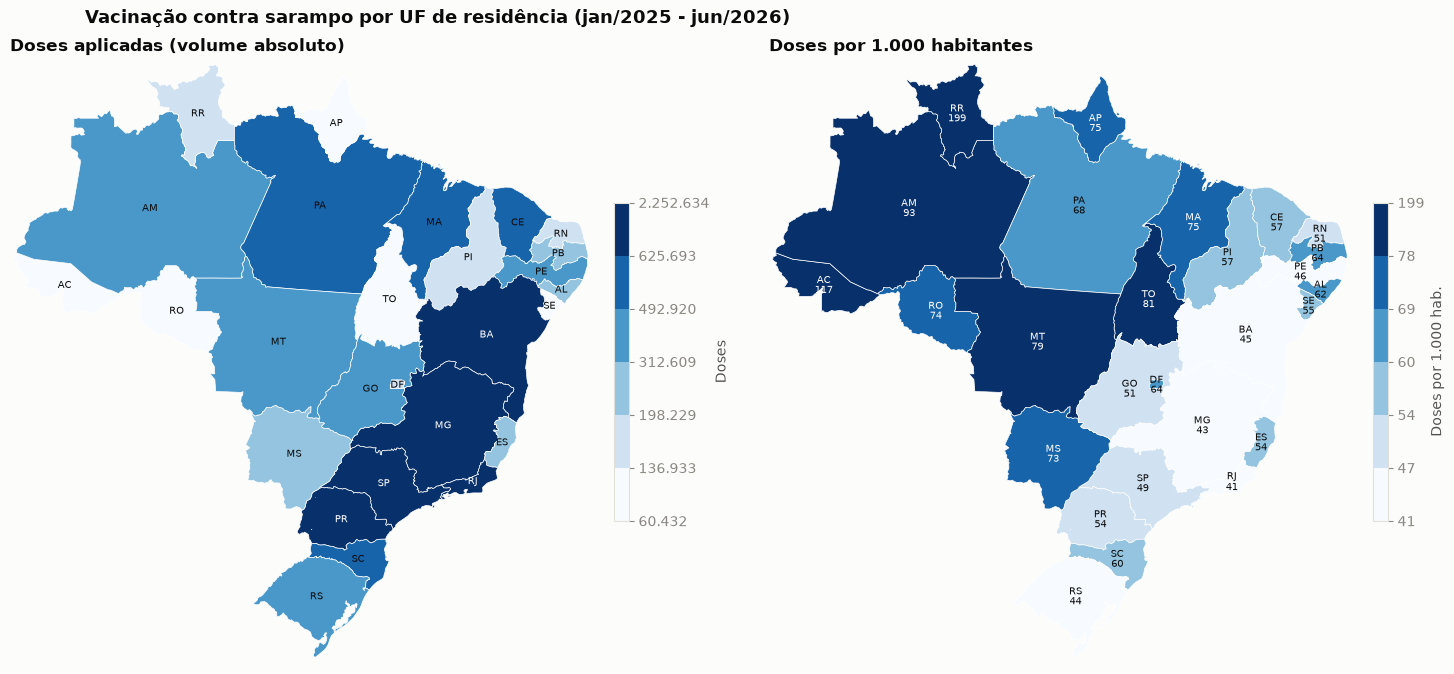

Maiores taxas: {'RR': 199.0, 'AC': 117.0, 'AM': 93.0, 'TO': 81.0, 'MT': 79.0}
Menores taxas: {'PE': 46.0, 'BA': 45.0, 'RS': 44.0, 'MG': 43.0, 'RJ': 41.0}


In [2]:
taxa_uf = (doses_uf / pop_uf * 1000).dropna()
taxa_uf = taxa_uf[taxa_uf.index.isin(sigla_uf)]
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
abs_uf = doses_uf[doses_uf.index.isin(sigla_uf)]
coropletico(axes[0], abs_uf.to_dict(), bins=quantis(abs_uf, 6), cmap="Blues", titulo="Doses aplicadas (volume absoluto)", rotulo="Doses", cbar_kw={"shrink": 0.5})
b0 = quantis(abs_uf, 6)
rotular_uf(axes[0], None, so_sigla=True, escuro=set(abs_uf[abs_uf > b0[-2]].index))
b = quantis(taxa_uf, 6)
coropletico(axes[1], taxa_uf.to_dict(), bins=b, cmap="Blues", titulo="Doses por 1.000 habitantes", rotulo="Doses por 1.000 hab.", cbar_kw={"shrink": 0.5})
rotular_uf(axes[1], taxa_uf.to_dict(), fmt="{:.0f}", limiar=b[-3])
fig.suptitle("Vacinação contra sarampo por UF de residência (jan/2025 - jun/2026)", x=0.06, ha="left", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()
t = taxa_uf.sort_values(ascending=False)
print("Maiores taxas:", t.head(5).round(0).to_dict()); print("Menores taxas:", t.tail(5).round(0).to_dict())

## 3. Doses por 1.000 habitantes, por município
Mesma taxa em resolução municipal (5.570 municípios). Cores por quantil: cada tom representa a mesma quantidade de municípios. Municípios muito pequenos têm taxas instáveis.

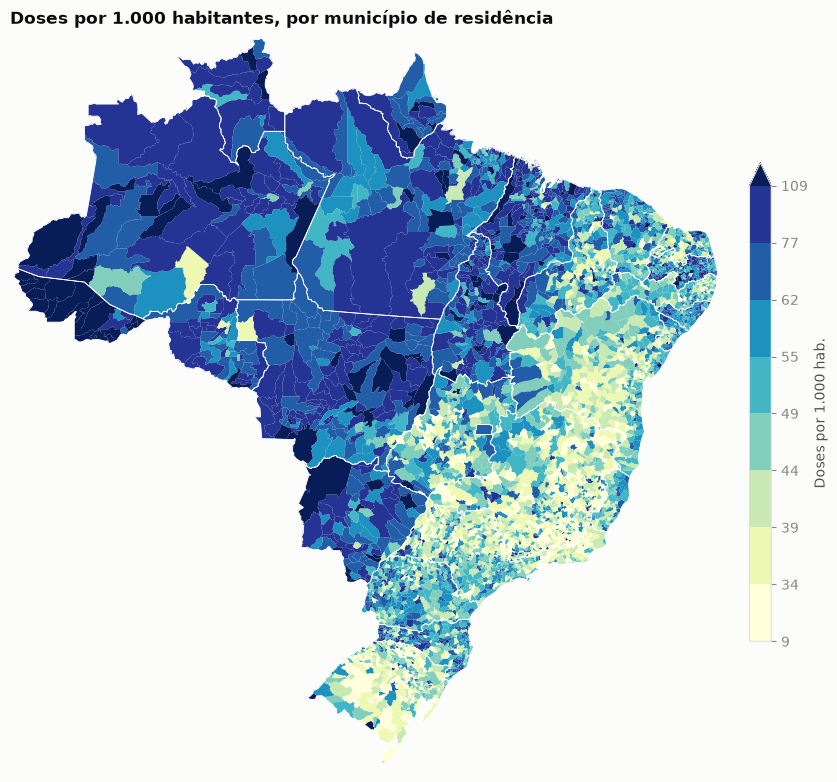

Mediana municipal: 49 por 1.000 hab. | P10 = 32 | P90 = 82
Municípios sem dado no mapa: 0 | taxas acima do P97 (última cor): 168


In [3]:
dm = pd.DataFrame({"doses": doses_mun}).join(pop_mun, how="inner")
dm["taxa"] = dm["doses"] / dm["populacao"] * 1000
taxa_mun = dm["taxa"].to_dict()
b = quantis(dm["taxa"].clip(upper=dm["taxa"].quantile(0.97)), 8)  # o 1º e o último tom absorvem os extremos
fig, ax = plt.subplots(figsize=(9, 9))
coropletico(ax, taxa_mun, nivel="mun", bins=b, cmap="YlGnBu", extremos="max",
            titulo="Doses por 1.000 habitantes, por município de residência", rotulo="Doses por 1.000 hab.", fmt="{:,.0f}")
plt.tight_layout(); plt.show()
print(f"Mediana municipal: {dm['taxa'].median():.0f} por 1.000 hab. | P10 = {dm['taxa'].quantile(.1):.0f} | P90 = {dm['taxa'].quantile(.9):.0f}")
print("Municípios sem dado no mapa:", len(set(cod_mun) - set(dm.index)), "| taxas acima do P97 (última cor):", int((dm["taxa"] > dm["taxa"].quantile(0.97)).sum()))

### Taxas municipais extremas
Municípios com as maiores e menores taxas, restritos a pelo menos 5.000 habitantes para evitar ruído de cidades minúsculas.

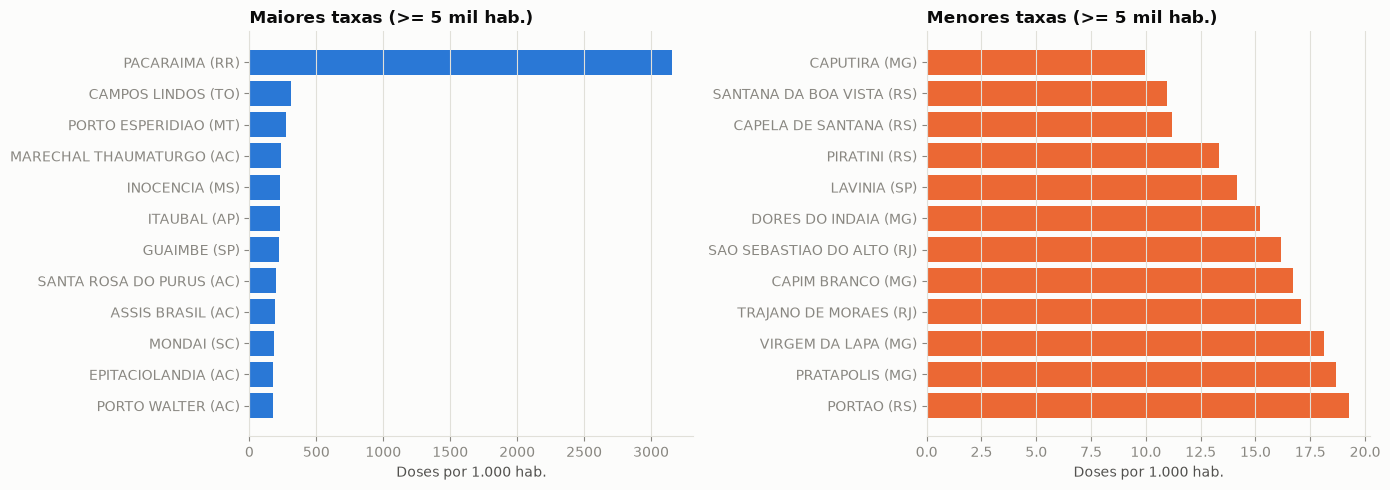

In [4]:
dm2 = dm[dm["populacao"] >= 5000].join(dim.set_index("codigo_municipio")[["municipio", "uf"]])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top = dm2.nlargest(12, "taxa").iloc[::-1]; bot = dm2.nsmallest(12, "taxa").iloc[::-1]
axes[0].barh(top["municipio"] + " (" + top["uf"] + ")", top["taxa"], color=BLUE); axes[0].set_title("Maiores taxas (>= 5 mil hab.)", loc="left", fontweight="bold")
axes[1].barh(bot["municipio"] + " (" + bot["uf"] + ")", bot["taxa"], color=CATEGORICAL[1]); axes[1].set_title("Menores taxas (>= 5 mil hab.)", loc="left", fontweight="bold")
for a in axes: a.set_xlabel("Doses por 1.000 hab."); a.grid(axis="x", color=GRID)
plt.tight_layout(); plt.show()

## 4. Onde as doses se concentram (mapa de bolhas)
Cada círculo é um município, com área proporcional às doses. Mostra a **geografia da população vacinada**: litoral, capitais e grandes regiões metropolitanas.

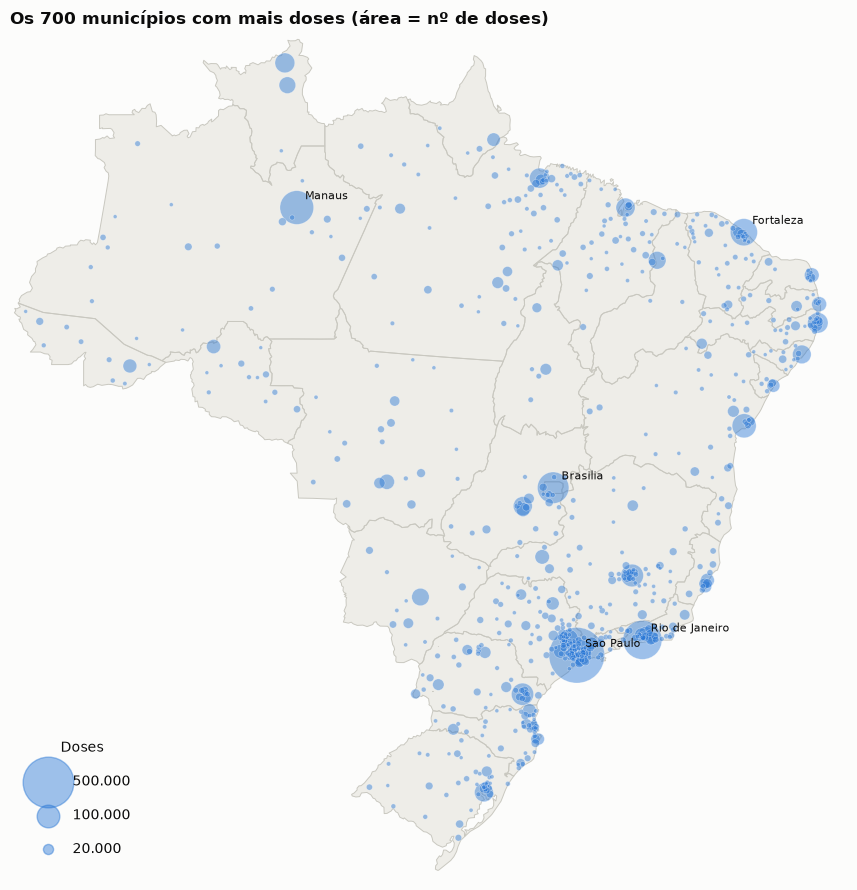

In [5]:
cm = centroides(cod_mun, verts_mun, dono_mun)
d = pd.DataFrame({"doses": doses_mun}).dropna()
d = d[d.index.isin(cm)].nlargest(700, "doses")
xy = np.array([cm[c] for c in d.index])
fig, ax = plt.subplots(figsize=(9, 9))
base_mapa(ax, cor_uf="#c9c8c0", lw=0.7)
ax.add_collection(PolyCollection(verts_uf, facecolors="#eeede8", edgecolors="none", zorder=0))
ax.scatter(xy[:, 0], xy[:, 1], s=d["doses"] / d["doses"].max() * 1600, color=BLUE, alpha=0.45, edgecolors="white", linewidths=0.4, zorder=4)
for ref in [500_000, 100_000, 20_000]:
    ax.scatter([], [], s=ref / d["doses"].max() * 1600, color=BLUE, alpha=0.45, label=f"{ref:,}".replace(",", "."))
ax.legend(title="Doses", loc="lower left", frameon=False, labelspacing=1.4, borderpad=1.2)
ax.set_title("Os 700 municípios com mais doses (área = nº de doses)", loc="left", fontweight="bold")
top5 = d.head(5).join(dim.set_index("codigo_municipio")["municipio"])
for c, r in top5.iterrows():
    ax.annotate(r["municipio"].title().replace(" De ", " de "), cm[c], xytext=(6, 6), textcoords="offset points", fontsize=8, zorder=7)
plt.tight_layout(); plt.show()

## 5. Evolução no tempo: um mapa por trimestre
Todos os painéis usam a **mesma escala de cor** (doses por 1.000 hab. no trimestre), então mudanças de tom indicam mudança real de ritmo. O 2º tri de 2026 está completo até junho.

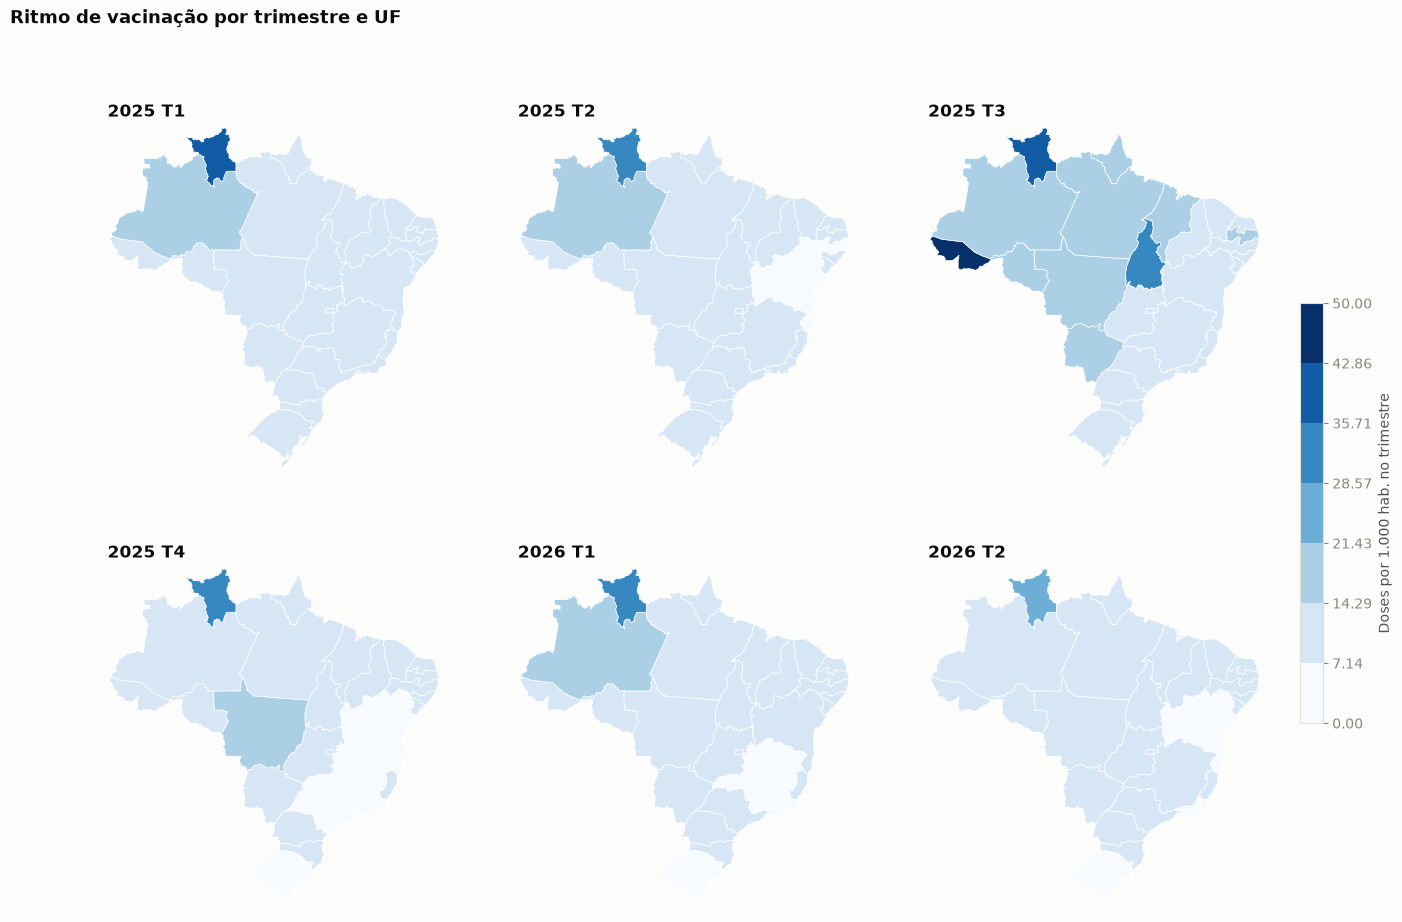

In [6]:
uf_mes["tri"] = pd.PeriodIndex(uf_mes["ano_mes"], freq="M").asfreq("Q").astype(str)
tri = uf_mes.groupby(["tri", "uf_paciente"])["doses"].sum().unstack(0)
tri = tri.loc[tri.index.isin(sigla_uf)]
taxa = tri.div(pop_uf.reindex(tri.index), axis=0) * 1000
bins = np.linspace(taxa.min().min() // 5 * 5, np.ceil(taxa.max().max() / 5) * 5, 8)
fig, axes = plt.subplots(2, 3, figsize=(15, 10.5))
for ax, col in zip(axes.ravel(), taxa.columns):
    pc = coropletico(ax, taxa[col].to_dict(), bins=bins, cmap="Blues", titulo=col.replace("Q", " T"), colorbar=False)
fig.subplots_adjust(right=0.9)
cb = fig.colorbar(pc, cax=fig.add_axes([0.92, 0.3, 0.015, 0.4])); cb.set_label("Doses por 1.000 hab. no trimestre")
fig.suptitle("Ritmo de vacinação por trimestre e UF", x=0.06, ha="left", fontweight="bold", fontsize=13)
plt.show()

## 6. 2026 x 2025: onde a vacinação cresceu ou caiu
Variação percentual das doses no 1º semestre (jan-jun) de 2026 contra o de 2025, por UF. Escala divergente centrada em zero: **azul = cresceu, laranja = caiu**.

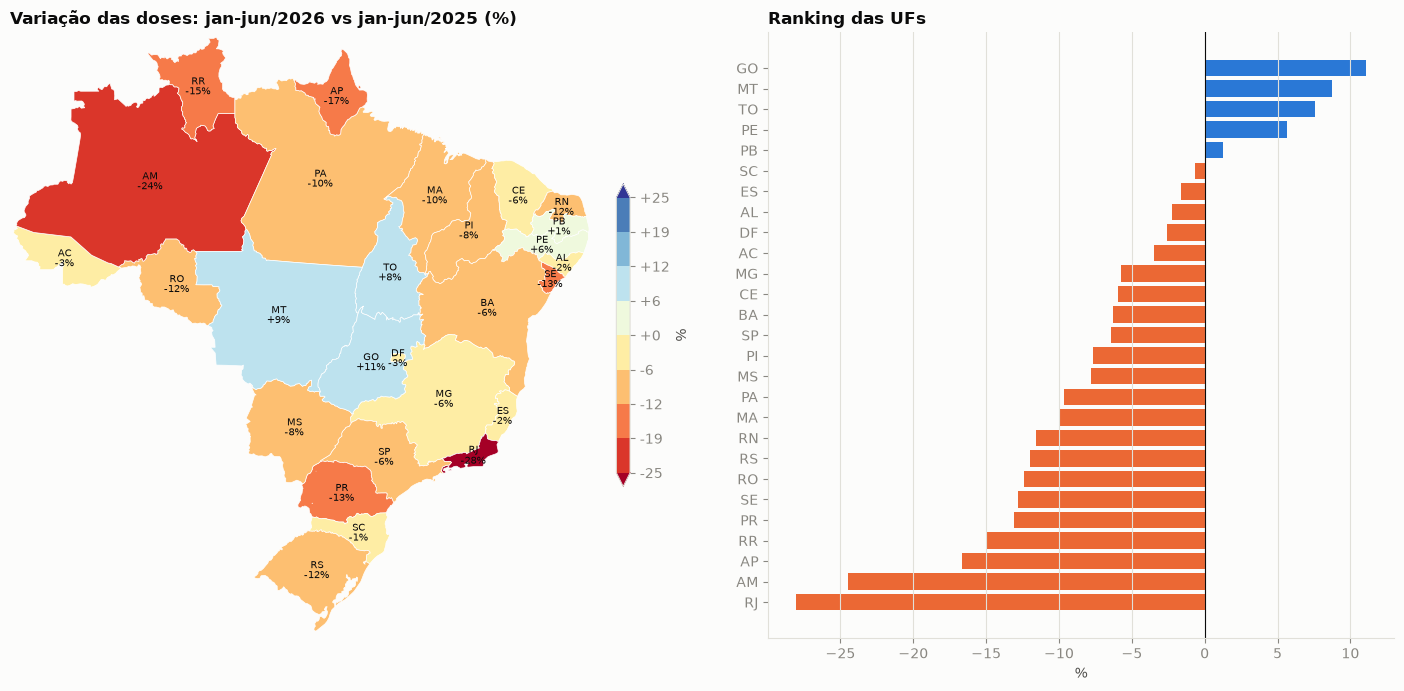

Brasil: -8.0% | UFs com queda: 22 de 27


In [7]:
s = uf_mes[uf_mes["uf_paciente"].isin(sigla_uf)].copy()
s["ano"] = s["ano_mes"].str[:4].astype(int); s["mes"] = s["ano_mes"].str[5:].astype(int)
s = s[s["mes"] <= 6].groupby(["uf_paciente", "ano"])["doses"].sum().unstack()
var = ((s[2026] / s[2025] - 1) * 100).dropna()
lim = np.ceil(np.abs(var).quantile(0.95) / 5) * 5
bins = np.linspace(-lim, lim, 9)
fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.3, 1]})
coropletico(axes[0], var.to_dict(), bins=bins, cmap="RdYlBu", extremos="both", titulo="Variação das doses: jan-jun/2026 vs jan-jun/2025 (%)", rotulo="%", fmt="{:+.0f}", cbar_kw={"shrink": 0.5})
rotular_uf(axes[0], var.to_dict(), fmt="{:+.0f}%", so_sigla=False)
ordem = var.sort_values()
axes[1].barh(ordem.index, ordem.values, color=[CATEGORICAL[1] if x < 0 else BLUE for x in ordem.values])
axes[1].axvline(0, color=TEXT_PRIMARY, linewidth=0.8); axes[1].set_xlabel("%"); axes[1].grid(axis="x", color=GRID)
axes[1].set_title("Ranking das UFs", loc="left", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Brasil: {(s[2026].sum() / s[2025].sum() - 1) * 100:+.1f}% | UFs com queda: {(var < 0).sum()} de {len(var)}")

## 7. Crianças de 1 a 4 anos: quem voltou para a 2ª dose
Entre as crianças vacinadas de 1 a 4 anos, a proporção que já tem **2 ou mais doses**. Não é cobertura (o denominador é quem já entrou no esquema), mas separa os municípios em que a criança vacinada completa o esquema dos que perdem a criança depois da 1ª dose. Só municípios com pelo menos 100 crianças vacinadas (o cinza no mapa é "sem dado suficiente").

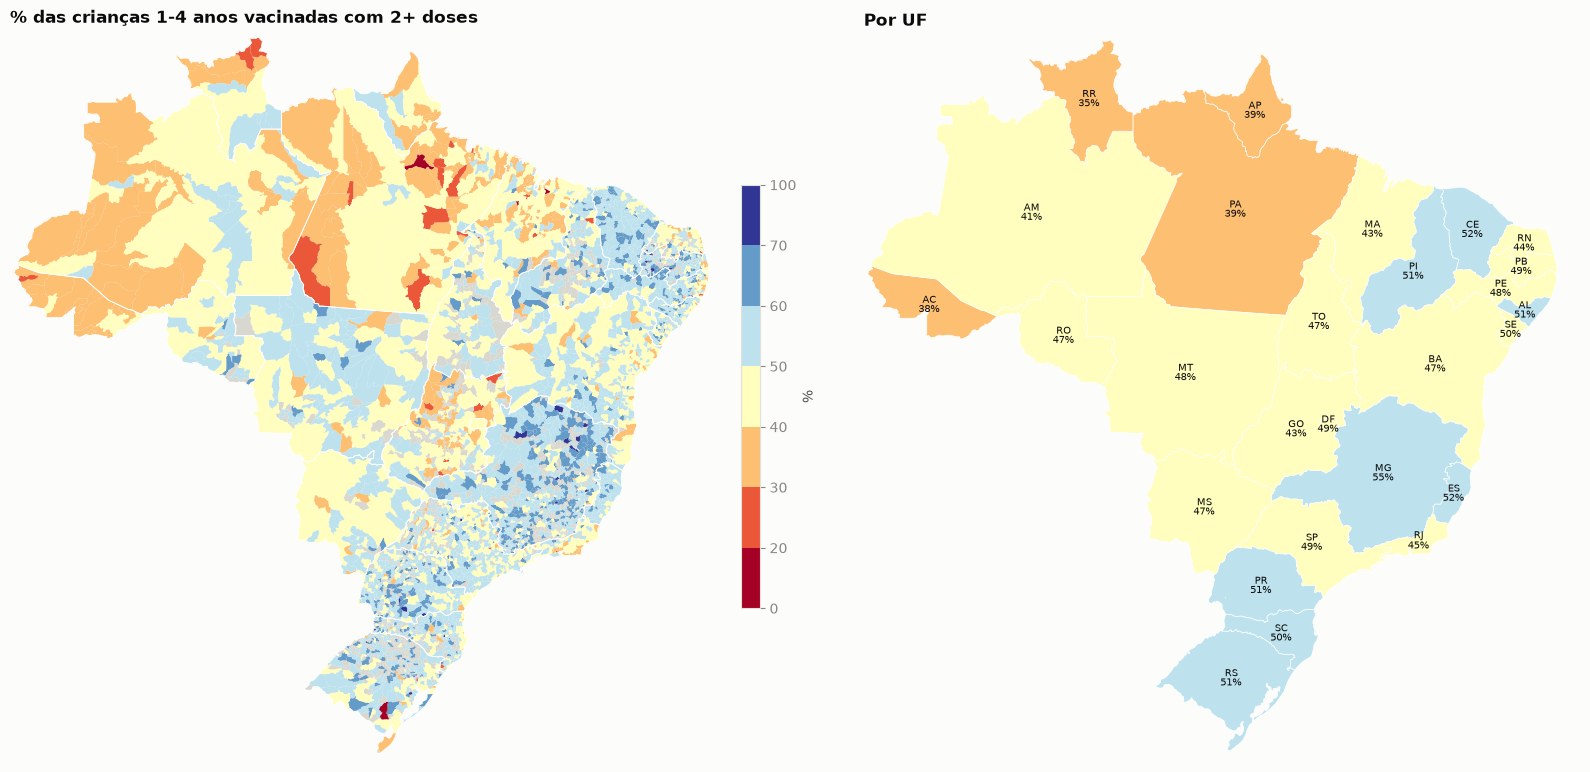

4,343 municípios no mapa | mediana = 51.7% | menor UF: RR (34.8%), maior UF: MG (54.9%)


In [8]:
c = coorte[coorte["criancas_vacinadas"] >= 100].copy()
c["codigo_municipio_paciente"] = c["codigo_municipio_paciente"].astype(str)
prop = (c.set_index("codigo_municipio_paciente")["prop_com_2_ou_mais"] * 100)
b = np.array([0, 20, 30, 40, 50, 60, 70, 100.01])
fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [1.2, 1]})
coropletico(axes[0], prop.to_dict(), nivel="mun", bins=b, cmap="RdYlBu", titulo="% das crianças 1-4 anos vacinadas com 2+ doses", rotulo="%", fmt="{:.0f}")
ufp = coorte.groupby("uf_paciente")[["criancas_vacinadas", "criancas_com_2_ou_mais_doses"]].sum()
ufp = (ufp["criancas_com_2_ou_mais_doses"] / ufp["criancas_vacinadas"] * 100)
ufp = ufp[ufp.index.isin(sigla_uf)]
coropletico(axes[1], ufp.to_dict(), bins=b, cmap="RdYlBu", titulo="Por UF", colorbar=False)
rotular_uf(axes[1], ufp.to_dict(), fmt="{:.0f}%", tamanho=7)
plt.tight_layout(); plt.show()
print(f"{len(c):,} municípios no mapa | mediana = {prop.median():.1f}% | menor UF: {ufp.idxmin()} ({ufp.min():.1f}%), maior UF: {ufp.idxmax()} ({ufp.max():.1f}%)")

## 8. Adultos: onde se vacinam adultos de 20 a 59 anos
Percentual das doses de cada UF aplicadas em adultos de 20 a 59 anos. Valores altos apontam para **bloqueios, campanhas de atualização ou surtos** e não para a rotina infantil.

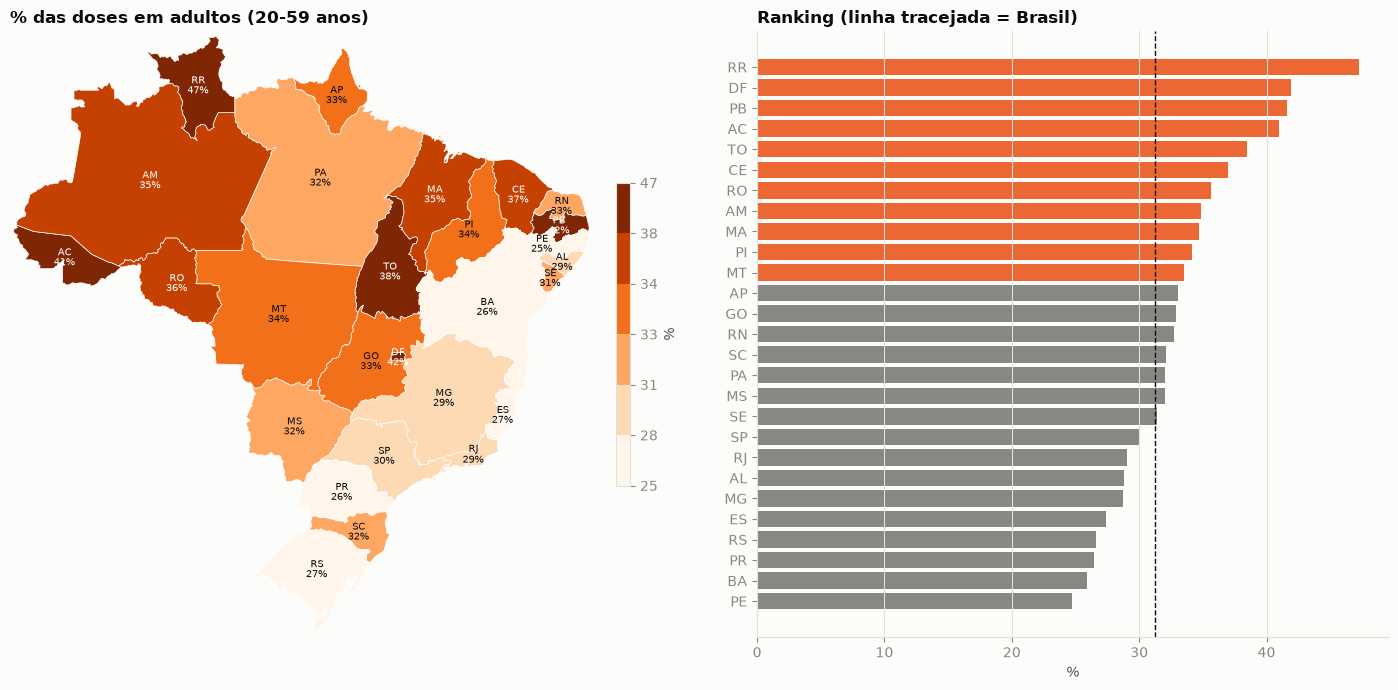

In [9]:
adultos = ["20-29", "30-39", "40-49", "50-59"]
p = perfil[perfil["uf_paciente"].isin(sigla_uf)]
tot = p.groupby("uf_paciente")["doses"].sum()
ad = p[p["faixa_etaria"].isin(adultos)].groupby("uf_paciente")["doses"].sum()
pct_ad = (ad / tot * 100).dropna()
b = quantis(pct_ad, 6)
fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.3, 1]})
coropletico(axes[0], pct_ad.to_dict(), bins=b, cmap="Oranges", titulo="% das doses em adultos (20-59 anos)", rotulo="%", fmt="{:.0f}", cbar_kw={"shrink": 0.5})
rotular_uf(axes[0], pct_ad.to_dict(), fmt="{:.0f}%", limiar=b[-3])
o = pct_ad.sort_values()
axes[1].barh(o.index, o.values, color=[CATEGORICAL[1] if x > pct_ad.mean() else MUTED for x in o.values])
axes[1].axvline(ad.sum() / tot.sum() * 100, color=TEXT_PRIMARY, linestyle="--", linewidth=1); axes[1].set_xlabel("%"); axes[1].grid(axis="x", color=GRID)
axes[1].set_title("Ranking (linha tracejada = Brasil)", loc="left", fontweight="bold")
plt.tight_layout(); plt.show()

## 9. Atraso no registro: onde os dados chegam tarde
Percentual das doses registradas no RNDS com **mais de 30 dias de atraso** em relação à data da vacinação. Onde é alto, os números recentes ficam subestimados por mais tempo.

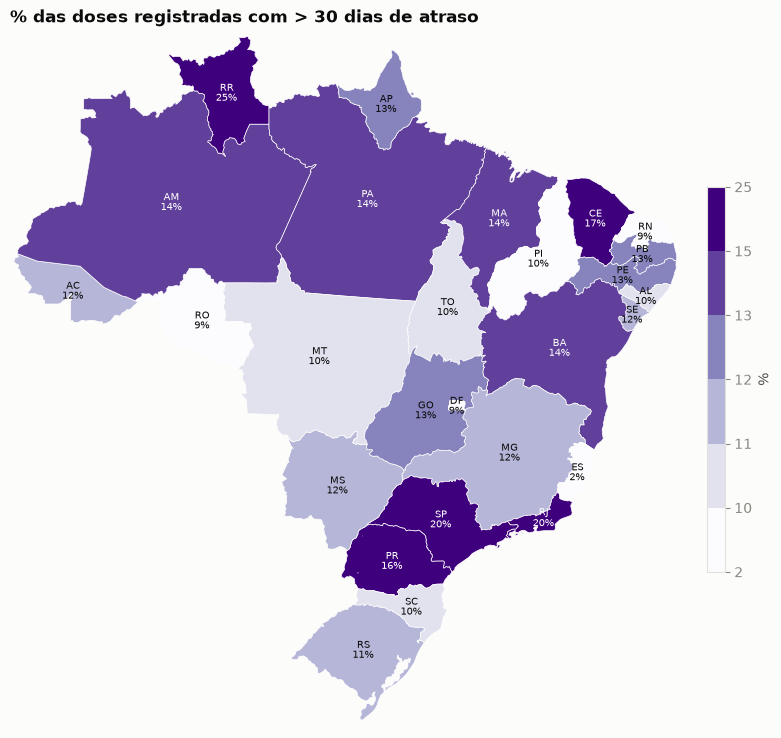

Maior atraso: {'RR': 24.9, 'SP': 20.3, 'RJ': 19.7, 'CE': 17.0} | menor: {'ES': 1.6, 'DF': 8.8, 'RN': 9.3, 'RO': 9.4}


In [10]:
a = atraso[atraso["uf_paciente"].isin(sigla_uf)]
tot = a.groupby("uf_paciente")["doses"].sum()
tarde = a[a["faixa_atraso"].isin(["31-90 dias", "> 90 dias"])].groupby("uf_paciente")["doses"].sum()
pct_t = (tarde / tot * 100).dropna()
b = quantis(pct_t, 6)
fig, ax = plt.subplots(figsize=(8.5, 8))
coropletico(ax, pct_t.to_dict(), bins=b, cmap="Purples", titulo="% das doses registradas com > 30 dias de atraso", rotulo="%", fmt="{:.0f}", cbar_kw={"shrink": 0.5})
rotular_uf(ax, pct_t.to_dict(), fmt="{:.0f}%", limiar=b[-3])
plt.tight_layout(); plt.show()
print("Maior atraso:", pct_t.nlargest(4).round(1).to_dict(), "| menor:", pct_t.nsmallest(4).round(1).to_dict())

## 10. Fluxos interestaduais
Doses aplicadas em uma UF a pacientes residentes em outra. Cada seta vai da **UF de residência para a UF onde a dose foi aplicada**, com espessura proporcional ao número de doses (30 maiores fluxos). Revela polos de atração (capitais, fronteiras) e deslocamentos por trabalho.

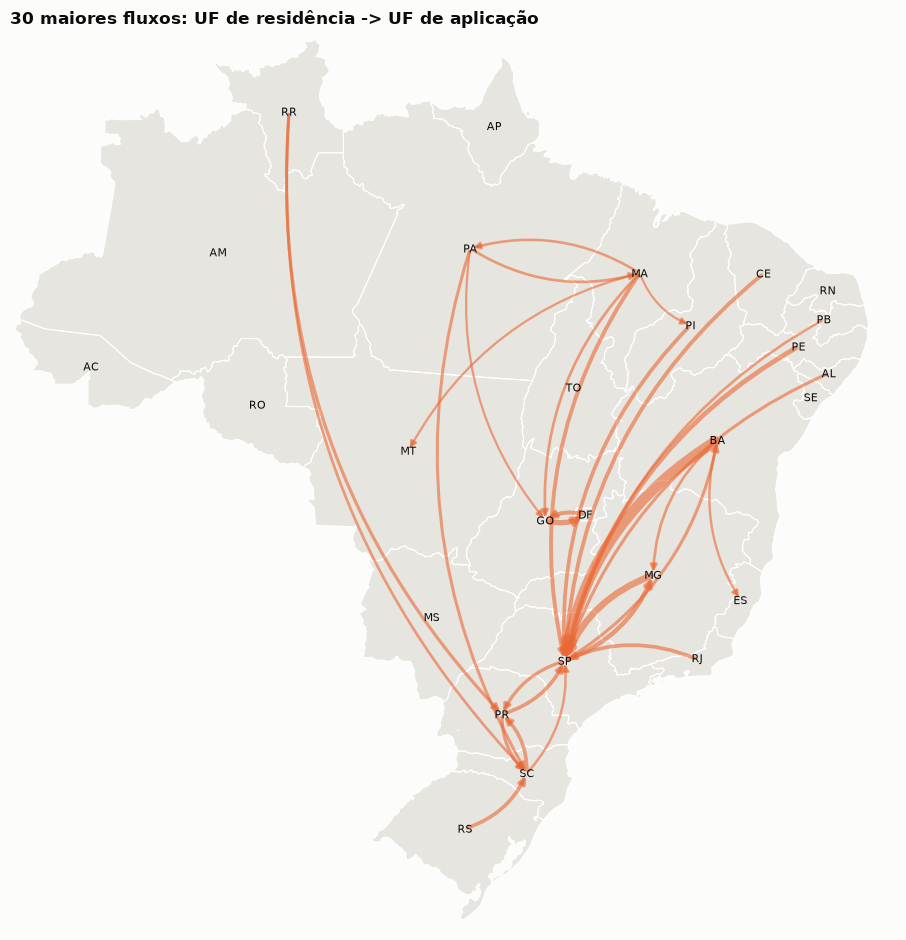

Maiores fluxos:


,uf_paciente,uf_estabelecimento,doses
0,BA,SP,26185
1,MG,SP,15499
2,GO,DF,12263
3,PE,SP,10553
4,SP,MG,9841
5,DF,GO,8556
6,CE,SP,8228
7,MA,SP,8226


Saldo (doses recebidas de outras UFs - doses de residentes aplicadas fora):
Recebem mais: {'SP': 81398, 'SC': 19659, 'PR': 16598, 'DF': 7992} | enviam mais: {'BA': -34066, 'RR': -16852, 'PA': -16409, 'MA': -12422}


In [11]:
fl = pd.read_parquet(SILVER, columns=["uf_paciente", "uf_estabelecimento"]).dropna()
fl = fl[fl["uf_paciente"] != fl["uf_estabelecimento"]]
fl = fl.groupby(["uf_paciente", "uf_estabelecimento"]).size().rename("doses").reset_index()
fl = fl[fl["uf_paciente"].isin(sigla_uf) & fl["uf_estabelecimento"].isin(sigla_uf)]
top = fl.nlargest(30, "doses")
fig, ax = plt.subplots(figsize=(9.5, 9.5))
base_mapa(ax, cor_uf="white", lw=0.8)
ax.add_collection(PolyCollection(verts_uf, facecolors="#e6e5df", edgecolors="none", zorder=0))
for _, r in top.iterrows():
    p0, p1 = cent_uf[r["uf_paciente"]], cent_uf[r["uf_estabelecimento"]]
    ax.add_patch(FancyArrowPatch(p0, p1, connectionstyle="arc3,rad=0.22", arrowstyle="-|>", mutation_scale=9 + 0.0004 * r["doses"] ** 0.5 * 30,
                                 linewidth=0.6 + r["doses"] / top["doses"].max() * 7, color=CATEGORICAL[1], alpha=0.6, zorder=5))
rotular_uf(ax, None, so_sigla=True, tamanho=8)
ax.set_title("30 maiores fluxos: UF de residência -> UF de aplicação", loc="left", fontweight="bold")
plt.tight_layout(); plt.show()
sai = fl.groupby("uf_paciente")["doses"].sum(); entra = fl.groupby("uf_estabelecimento")["doses"].sum()
saldo = (entra.reindex(sigla_uf).fillna(0) - sai.reindex(sigla_uf).fillna(0))
saldo.index = sigla_uf
print("Maiores fluxos:"); display(top.head(8).reset_index(drop=True))
print("Saldo (doses recebidas de outras UFs - doses de residentes aplicadas fora):")
print("Recebem mais:", saldo.nlargest(4).astype(int).to_dict(), "| enviam mais:", saldo.nsmallest(4).astype(int).to_dict())

### Saldo por UF
Diferença entre doses recebidas de residentes de outras UFs e doses de seus residentes aplicadas em outras UFs (**azul = polo receptor, laranja = polo emissor**).

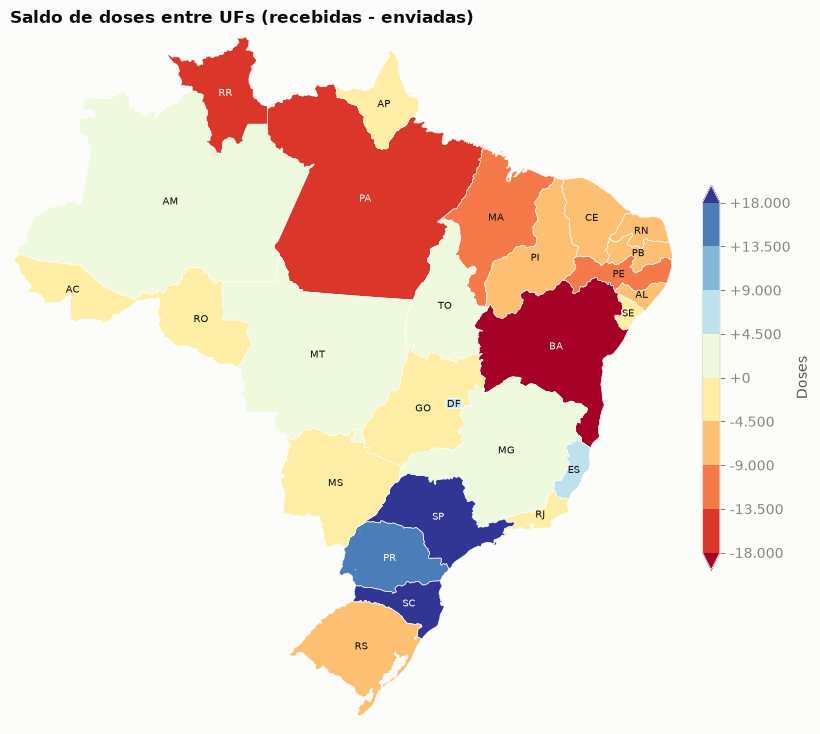

In [12]:
lim = np.ceil(np.abs(saldo).quantile(0.9) / 1000) * 1000
bins = np.linspace(-lim, lim, 9)
fig, ax = plt.subplots(figsize=(8.5, 8))
coropletico(ax, saldo.to_dict(), bins=bins, cmap="RdYlBu", extremos="both", titulo="Saldo de doses entre UFs (recebidas - enviadas)", rotulo="Doses", fmt="{:+,.0f}", cbar_kw={"shrink": 0.5})
rotular_uf(ax, None, so_sigla=True, escuro=set(saldo[saldo.abs() > lim * 0.75].index))
plt.tight_layout(); plt.show()

## 11. Síntese

In [13]:
print("SÍNTESE GEOGRÁFICA")
print(f"- Maior taxa por habitante (UF): {taxa_uf.idxmax()} ({taxa_uf.max():.0f} doses/1.000 hab.); menor: {taxa_uf.idxmin()} ({taxa_uf.min():.0f}).")
print(f"- Mediana municipal: {dm['taxa'].median():.0f} doses/1.000 hab. (P10 = {dm['taxa'].quantile(.1):.0f}, P90 = {dm['taxa'].quantile(.9):.0f}).")
print(f"- 1º semestre 2026 vs 2025: {(s[2026].sum() / s[2025].sum() - 1) * 100:+.1f}% no país; maior queda {var.idxmin()} ({var.min():+.0f}%), maior alta {var.idxmax()} ({var.max():+.0f}%).")
print(f"- Crianças 1-4 anos com 2+ doses: de {ufp.min():.0f}% ({ufp.idxmin()}) a {ufp.max():.0f}% ({ufp.idxmax()}).")
print(f"- Adultos 20-59 nas doses: de {pct_ad.min():.0f}% ({pct_ad.idxmin()}) a {pct_ad.max():.0f}% ({pct_ad.idxmax()}).")
print(f"- Atraso > 30 dias: de {pct_t.min():.0f}% ({pct_t.idxmin()}) a {pct_t.max():.0f}% ({pct_t.idxmax()}).")

SÍNTESE GEOGRÁFICA
- Maior taxa por habitante (UF): RR (199 doses/1.000 hab.); menor: RJ (41).
- Mediana municipal: 49 doses/1.000 hab. (P10 = 32, P90 = 82).
- 1º semestre 2026 vs 2025: -8.0% no país; maior queda RJ (-28%), maior alta GO (+11%).
- Crianças 1-4 anos com 2+ doses: de 35% (RR) a 55% (MG).
- Adultos 20-59 nas doses: de 25% (PE) a 47% (RR).
- Atraso > 30 dias: de 2% (ES) a 25% (RR).


## Próximos passos
1. **Cobertura por idade**: trocar a população total pela população de 1 a 4 anos (Censo 2022/SINASC) para calcular cobertura vacinal municipal de verdade.
2. **Casos x vacinação**: sobrepor os casos confirmados (`data/sarampo/`) a estes mapas para identificar municípios com casos e baixa vacinação.
3. **Malha de maior resolução** (`qualidade=intermediaria` na API do IBGE) para mapas de região metropolitana.
4. **Mapas interativos** (Plotly/Folium) a partir das mesmas tabelas gold.